In [ ]:
import zipfile

with zipfile.ZipFile('archive (6).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted successfully!")

Extracted successfully!


In [ ]:
import os

os.listdir()

['.config', 'archive (6).zip', 'Titanic-Dataset.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Shape:", df.shape)

df.info()

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
#Question 1: Survival by Gender
gender_survival = df.groupby(
    "Sex"
)["Survived"].mean()

print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


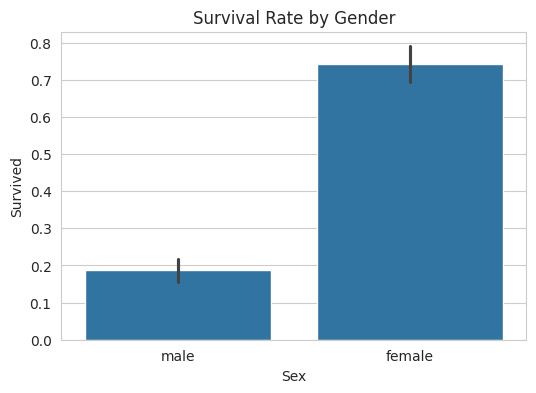

In [10]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Sex",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Gender")

plt.show()

In [11]:
#Question 2: Survival by Passenger Class
class_survival = df.groupby(
    "Pclass"
)["Survived"].mean()

print(class_survival)

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


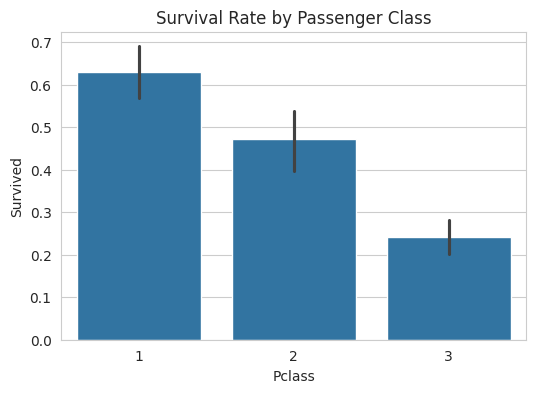

In [12]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Passenger Class")

plt.show()

In [13]:
#Question 3: Survival by Age Group
bins = [0,12,18,35,60,100]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_survival = df.groupby(
    "Age_Group"
)["Survived"].mean()

print(age_survival)

Age_Group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_1410/2942887176.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby(


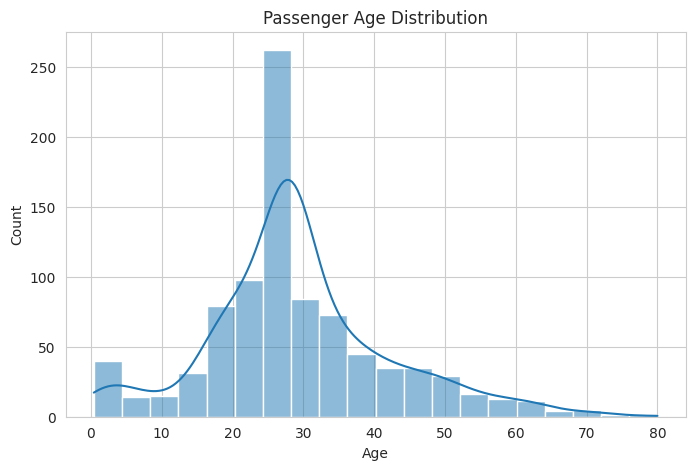

In [14]:
#Histogram of Passenger Ages
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title("Passenger Age Distribution")

plt.show()

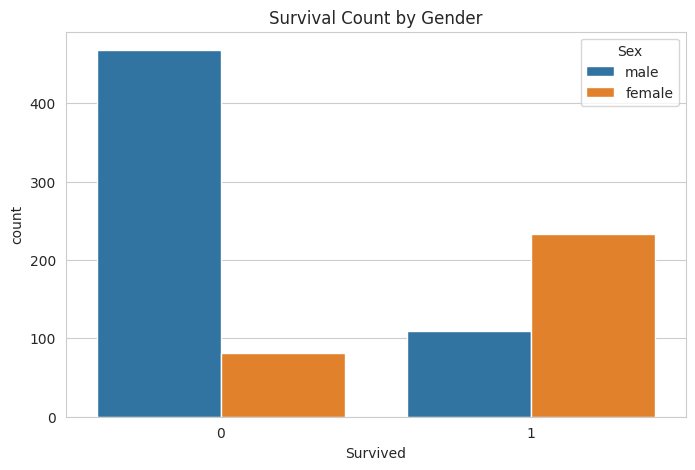

In [15]:
#Extra Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    x="Survived",
    hue="Sex",
    data=df
)

plt.title("Survival Count by Gender")

plt.show()

In [16]:
print("""
CONCLUSION

1. Female passengers survived more than males.
2. Passenger class significantly affected survival chances.
3. First-class passengers had the highest survival rate.
4. Most passengers were young adults.
5. Age played a role in survival patterns.
""")


CONCLUSION

1. Female passengers survived more than males.
2. Passenger class significantly affected survival chances.
3. First-class passengers had the highest survival rate.
4. Most passengers were young adults.
5. Age played a role in survival patterns.

